In [91]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import pickle

## Importing dataset

In [10]:
df = pd.read_csv('web_data.csv')

## Data Analysis and Preprocessing

In [3]:
df.head()

,Unnamed: 0,url,label,url_length,dot_count,dash_count,slash_count,at_count,digit_ratio,has_ip,has_bad_word,has_https
0,0,https://www.alaskansunset.com,0,29,2,0,2,0,0.000000,0,0,1
1,1,https://www.realbusinessrescue.co.uk,0,36,3,0,2,0,0.000000,0,0,1
2,2,https://sentinelpeakrv.com,0,26,1,0,2,0,0.000000,0,0,1
3,3,http://www.chesspals.com/,0,25,2,0,3,0,0.000000,0,0,0
4,4,https://www.marengo.k12.al.us,0,29,4,0,2,0,0.068966,0,0,1


In [11]:
df = df.iloc[:, 1:] # Removing first column

In [12]:
df.head()

,url,label,url_length,dot_count,dash_count,slash_count,at_count,digit_ratio,has_ip,has_bad_word,has_https
0,https://www.alaskansunset.com,0,29,2,0,2,0,0.000000,0,0,1
1,https://www.realbusinessrescue.co.uk,0,36,3,0,2,0,0.000000,0,0,1
2,https://sentinelpeakrv.com,0,26,1,0,2,0,0.000000,0,0,1
3,http://www.chesspals.com/,0,25,2,0,3,0,0.000000,0,0,0
4,https://www.marengo.k12.al.us,0,29,4,0,2,0,0.068966,0,0,1


In [16]:
df.shape

(2273771, 11)

## Checking for null values

In [13]:
df.isnull().sum()

url             0
label           0
url_length      0
dot_count       0
dash_count      0
slash_count     0
at_count        0
digit_ratio     0
has_ip          0
has_bad_word    0
has_https       0
dtype: int64

No null values are present in dataset

### Checking for duplicate values

In [14]:
df.duplicated().sum()

np.int64(99036)

As dataset have about 4.3% duplicate values so we can easily remove them


In [17]:
df = df.drop_duplicates()

In [18]:
df.duplicated().sum()

np.int64(0)

### Data Distribution

In [19]:
df['label'].value_counts()

label
0    1868769
1     305966
Name: count, dtype: int64

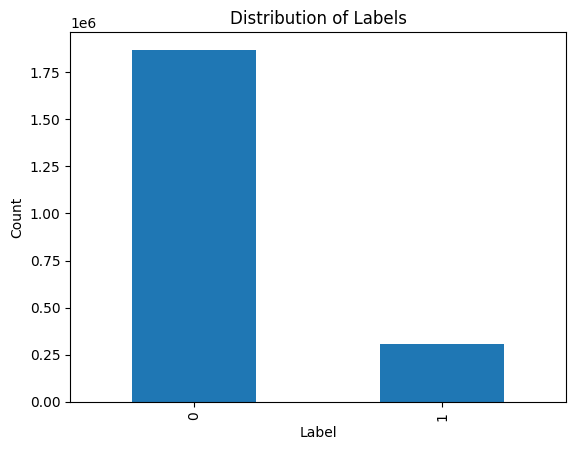

In [20]:
df['label'].value_counts().plot(kind='bar')
plt.xlabel('Label') 
plt.ylabel('Count')
plt.title('Distribution of Labels')
plt.show()

This imbalance in dataset is handeled during model training

### URL Cleaning

In [28]:
df['url'] = df['url'].str.lower()
df['url'] = df['url'].str.replace('http://', '')
df['url'] = df['url'].str.replace('https://', '')
df['url'] = df['url'].str.replace('/', '')

In [ ]:
df['url'] = df['url'].str.replace('www.', '')

In [ ]:
df['url'] = df['url'].str.split('#').str[0] # Removing fragments

In [29]:
df.head()

,url,label,url_length,dot_count,dash_count,slash_count,at_count,digit_ratio,has_ip,has_bad_word,has_https
0,alaskansunset.com,0,29,2,0,2,0,0.000000,0,0,1
1,realbusinessrescue.co.uk,0,36,3,0,2,0,0.000000,0,0,1
2,sentinelpeakrv.com,0,26,1,0,2,0,0.000000,0,0,1
3,chesspals.com,0,25,2,0,3,0,0.000000,0,0,0
4,marengo.k12.al.us,0,29,4,0,2,0,0.068966,0,0,1


##  Seperating dependent and independent variabbles

In [30]:
y = df['label']

In [31]:
y

0          0
1          0
2          0
3          0
4          0
          ..
2273748    0
2273751    0
2273752    0
2273753    0
2273754    0
Name: label, Length: 2174735, dtype: int64

In [32]:
x = df.drop(columns='label')

In [33]:
x

,url,url_length,dot_count,dash_count,slash_count,at_count,digit_ratio,has_ip,has_bad_word,has_https
0,alaskansunset.com,29,2,0,2,0,0.000000,0,0,1
1,realbusinessrescue.co.uk,36,3,0,2,0,0.000000,0,0,1
2,sentinelpeakrv.com,26,1,0,2,0,0.000000,0,0,1
3,chesspals.com,25,2,0,3,0,0.000000,0,0,0
4,marengo.k12.al.us,29,4,0,2,0,0.068966,0,0,1
...,...,...,...,...,...,...,...,...,...,...
2273748,gpscheap.com,24,2,0,3,0,0.000000,0,1,0
2273751,cleanridge.com,26,2,0,3,0,0.000000,0,0,0
2273752,creativepetgifts.com,32,2,0,3,0,0.000000,0,1,0
2273753,htmarket.com,24,2,0,3,0,0.000000,0,0,0


## train test Splitting

In [36]:
x_train,x_test,y_train,y_test= train_test_split(x,y,random_state = 42,test_size = 0.2)

## Feature engineering + cleaning Pipeline

In [63]:
bad_words = ['porn','xxx','sex','adult','nude','naked','boobs','breast','escort',
    'cam','cams','webcam','livecam','onlyfans','xvideo','xnxx','redtube',
    'hentai','bdsm','fetish','milf','teen','erotic','strip','stripchat','casino','bet','betting','poker','slot','jackpot','roulette',
    'blackjack','win','winnings','bonus','freebet','odds','gamble', 'free','offer','click','login','signup','verify','account',
    'secure','update','bonus','gift','promo','cheap','deal', 's3x','p0rn','pr0n','xxx','xnx','sexx','pron','sexyy']


class URLFeatureExtractor(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()

        # normalize
        X['url'] = X['url'].astype(str).str.lower()

        # basic structure features
        X['url_length'] = X['url'].str.len()
        X['dot_count'] = X['url'].str.count(r'\.')
        X['dash_count'] = X['url'].str.count('-')
        X['slash_count'] = X['url'].str.count('/')
        X['at_count'] = X['url'].str.count('@')

        # digit ratio (NO lambda)
        digit_count = X['url'].str.replace(r'\D', '', regex=True).str.len()
        length = X['url'].str.len().replace(0, 1)
        X['digit_ratio'] = digit_count / length

        # IP detection (NO lambda)
        X['has_ip'] = X['url'].str.contains(r'\d+\.\d+\.\d+\.\d+').astype(int)

        # HTTPS (NO lambda)
        X['has_https'] = X['url'].str.startswith('https').astype(int)

        # bad word detection (NO lambda)
        def check_bad_words(url):
            for word in bad_words:
                if word in url:
                    return 1
            return 0

        X['has_bad_word'] = X['url'].apply(check_bad_words)

        def clean_url(url):
            url = str(url).lower()

            url = url.replace('http://', '')
            url = url.replace('https://', '')
            url = url.replace('www.', '')

            url = url.split('#')[0]   # remove fragments
            

            url = url.replace('/', '')  

            return url
        
        X['url'] = X['url'].apply(clean_url)


        return X

In [44]:
def prepare_input(url):
     return create_feature_dataframe(url)
    
    

## Tf-idf Vectorizer

In [46]:
text_features = 'url'

numeric_features = [
    'has_bad_word',
    'has_https',
    'url_length',
    'dot_count',
    'dash_count',
    'slash_count',
    'at_count',
    'digit_ratio',
    'has_ip'
]

In [68]:
preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf', TfidfVectorizer(max_features=5000,token_pattern=r'[a-zA-Z0-9\-\.]+'), text_features),
        ('num', 'passthrough', numeric_features)
    ]
)

## Model Defining

In [84]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight= len(y_train[y_train==0]) / len(y_train[y_train==1]),
    eval_metric='logloss',
    use_label_encoder=False
)

## Defining Pipeline

In [85]:
pipeline = Pipeline([
    ('feature_extraction',URLFeatureExtractor()),
    ('preprocessor', preprocessor),
    ('model', model)
])

## Model Training

In [86]:
pipeline.fit(x_train,y_train)

d:\FYP\Project_final\26-FYP-CS-103\models\venv\lib\site-packages\xgboost\training.py:200: UserWarning: [16:16:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,steps,"[('feature_extraction', ...), ('preprocessor', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('tfidf', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Model Prediction

In [ ]:
y_pred = pipeline.predict(x_test)

## Model Evaluation

#### Checking accuracy

In [88]:
accuracy_score(y_test,y_pred)

0.9071404102108993

#### Classification Report

In [89]:
classification_report(y_test,y_pred)

'              precision    recall  f1-score   support\n\n           0       0.96      0.93      0.95    373835\n           1       0.64      0.77      0.70     61112\n\n    accuracy                           0.91    434947\n   macro avg       0.80      0.85      0.82    434947\nweighted avg       0.92      0.91      0.91    434947\n'

#### Confusion Matrix

In [93]:
confusion_matrix(y_test,y_pred)

array([[347708,  26127],
       [ 14262,  46850]])

## Model Saving

In [ ]:
with open("WebAnalysisModel.pkl", "wb") as f:
    pickle.dump(pipeline, f)